<a href="https://colab.research.google.com/github/thasnissam/Fathima-Thasni/blob/master/Notebooks/Analytics_in_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Python Data Processing

####Importing and Combining Data

Library Activation and Environment Setup

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Define source path for reproducible ingestion
base_url = "https://raw.githubusercontent.com/thasnissam/NorthStar_Data_Analytics_Project/main/Data/"

Seamless Data Ingestion

In [2]:
# Importing core datasets from GitHub
customers = pd.read_csv(base_url + "customers.csv")
orders = pd.read_csv(base_url + "orders.csv")
deliveries = pd.read_csv(base_url + "deliveries.csv")
hubs = pd.read_csv(base_url + "hubs.csv")
# Importing additional datasets from GitHub as identified in earlier discussions
complaints = pd.read_csv(base_url + "complaints.csv")
vehicles = pd.read_csv(base_url + "vehicles.csv")

print("Complaints DataFrame Shape:", complaints.shape)
print("Vehicles DataFrame Shape:", vehicles.shape)

Complaints DataFrame Shape: (320, 10)
Vehicles DataFrame Shape: (120, 8)


Master Data Frame Consolidation

In [3]:
# Removing duplicates
deliveries = deliveries.drop_duplicates(subset='order_id')
# vehicles = vehicles.drop_duplicates(subset='vehicle_id')
hubs = hubs.drop_duplicates(subset='hub_id')

# Creating master dataframe
master_df = orders.merge(customers, on='customer_id', how='left')

master_df = master_df.merge(
    deliveries,
    on='order_id',
    how='left'
)
master_df = master_df.merge(
    hubs,
    on='hub_id',
    how='left'
)

print("Master DataFrame Shape:", master_df.shape)
print("Master DataFrame Shape after merging vehicles:", master_df.shape)

Master DataFrame Shape: (1250, 35)
Master DataFrame Shape after merging vehicles: (1250, 35)


Missing Value Analysis

In [4]:
print("Missing Ratings:",
      deliveries['customer_rating_post_delivery'].isnull().sum())

print("Missing Completion Time:",
      deliveries['delivery_completed_at'].isnull().sum())

print("Missing Preferred Channel:",
      customers['preferred_channel'].isnull().sum())

Missing Ratings: 14
Missing Completion Time: 19
Missing Preferred Channel: 13


Missing Value Treatment

In [5]:
deliveries['customer_rating_post_delivery'] = deliveries[
    'customer_rating_post_delivery'
].fillna(
    deliveries['customer_rating_post_delivery'].median()
)

customers['preferred_channel'] = customers[
    'preferred_channel'
].fillna("Unknown")

Deep Cleaning and Standardisation

In [6]:
master_df['pickup_zone'] = (
    master_df['pickup_zone']
    .str.upper()
    .str.strip()
)

master_df['pickup_zone'] = (
    master_df['pickup_zone']
    .replace('CTR', 'CENTRAL')
)

Removal of Invalid Records

In [7]:
before = len(deliveries)

deliveries = deliveries.dropna(
    subset=['delivery_completed_at']
)

after = len(deliveries)

print("Removed Records:", before - after)

Removed Records: 19


####Analyzing Data with NumPy and Pandas

NumPy-Driven Feature Engineering

In [8]:
mean_cost = (
    master_df['fuel_or_charge_cost']
    .dropna()
    .mean()
)

master_df['cost_efficiency'] = np.where(
    master_df['fuel_or_charge_cost'] < mean_cost,
    "Efficient",
    "High Cost"
)

Aggregation and Statistical Benchmarking

In [9]:
zone_summary = master_df.groupby('pickup_zone')[[
    'order_value',
    'fuel_or_charge_cost',
    'customer_rating_post_delivery'
]].mean().reset_index()

print(zone_summary)

  pickup_zone  order_value  fuel_or_charge_cost  customer_rating_post_delivery
0     AIRPORT   103.890694            17.077876                       3.984037
1     CENTRAL    88.450840            12.120345                       3.546036
2        EAST    91.774348            12.567051                       3.912078
3       NORTH    91.031897            12.072148                       3.896667
4   RIVERSIDE    85.340728            12.392437                       3.864492
5       SOUTH    90.584972            12.481727                       4.051825
6        WEST    88.273677            11.935351                       3.896316


Statistical Aggregation by Service Type

In [10]:
# Summarizing performance metrics for actionable insights
service_summary = master_df.groupby('service_type').agg({
    'fuel_or_charge_cost': 'mean',
    'customer_rating_post_delivery': 'mean',
    'manual_route_override_count': 'sum' # Changed 'overrides' to 'manual_route_override_count'
}).reset_index()

####Visualising Numerical Features

Multivariate Relationship Analysis (Pairwise Plots)

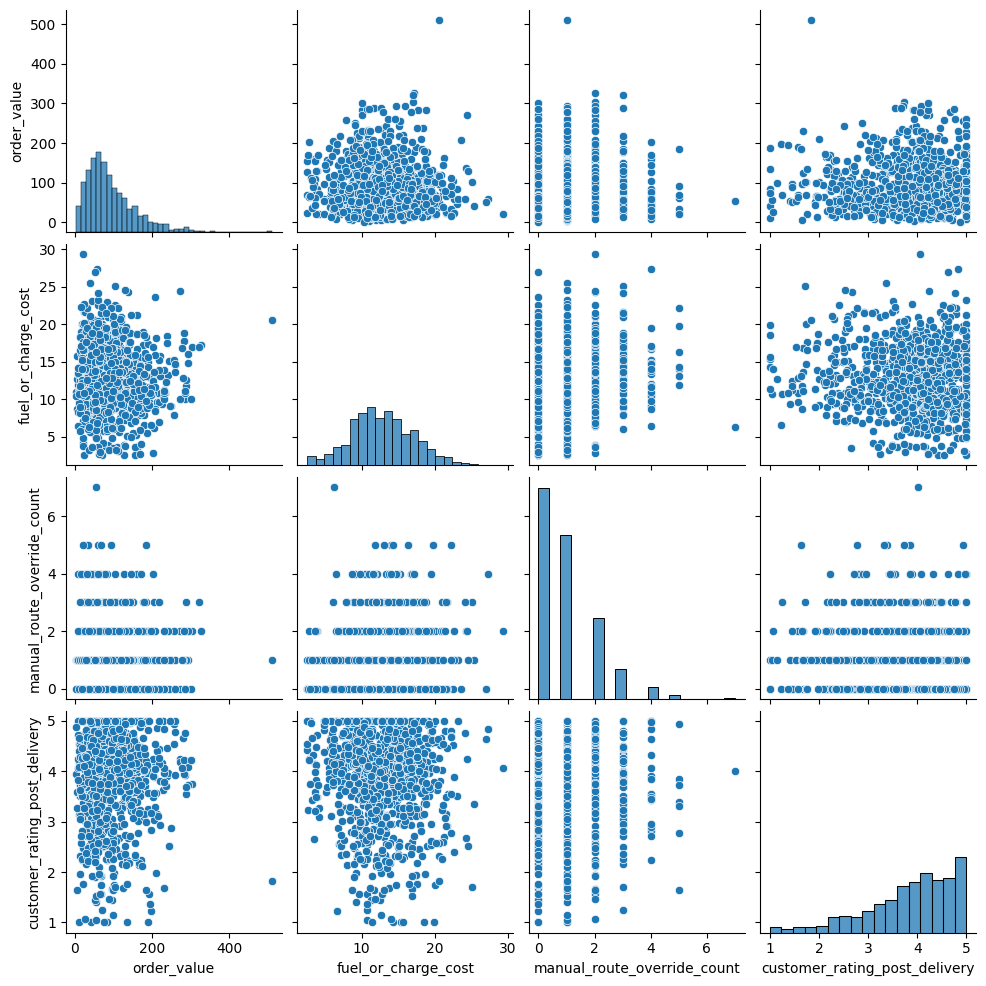

In [11]:
sns.pairplot(master_df[[
    'order_value',
    'fuel_or_charge_cost',
    'manual_route_override_count',
    'customer_rating_post_delivery'
]])

plt.show()

Operational Correlation Heatmap

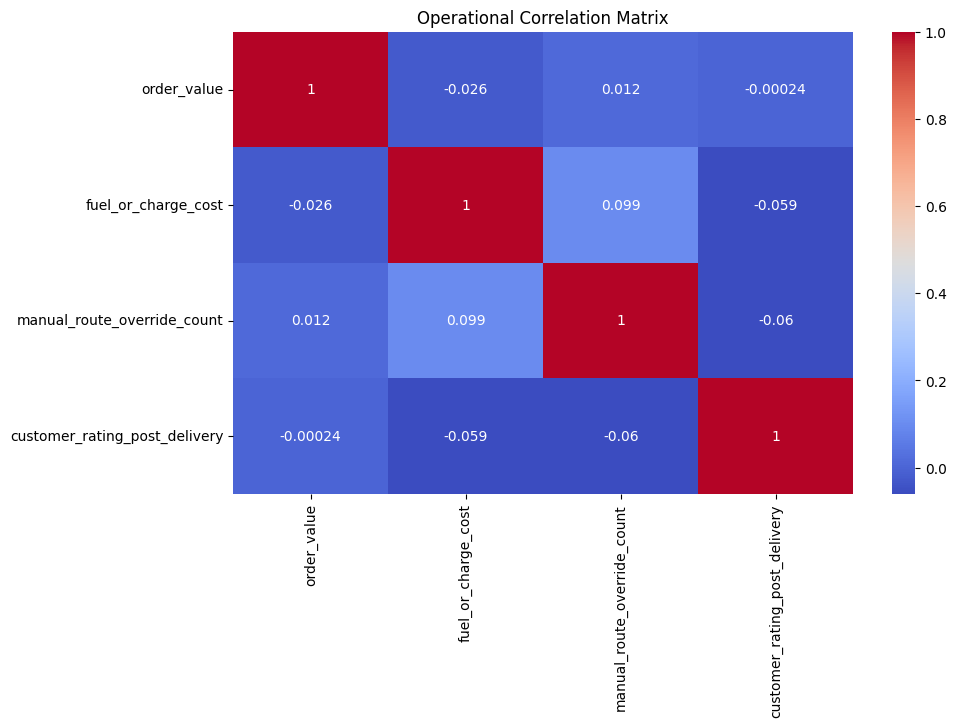

In [12]:
# Objective: Identify the strength of relationships between all numerical features
# Isolate numerical columns and calculate the Pearson correlation matrix
plt.figure(figsize=(10, 6))

sns.heatmap(
    master_df[[
        'order_value',
        'fuel_or_charge_cost',
        'manual_route_override_count',
        'customer_rating_post_delivery'
    ]].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Operational Correlation Matrix")

plt.show()

Pathway Analysis

Text(0.5, 1.0, 'Pathway Analysis: Flow of Efficient vs. High-Cost Journeys')

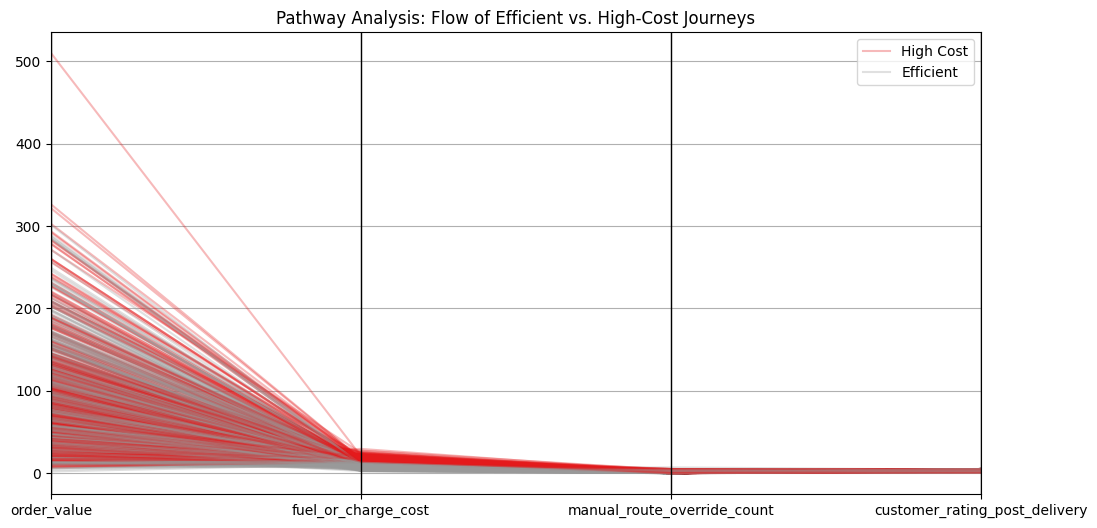

In [13]:
# Objective: Visualize the flow of individual journeys across multiple numerical scales
from pandas.plotting import parallel_coordinates

# Selecting a subset of metrics and categorizing by cost efficiency
cols = ['order_value', 'fuel_or_charge_cost', 'manual_route_override_count', 'customer_rating_post_delivery', 'cost_efficiency']
plt.figure(figsize=(12, 6))
parallel_coordinates(master_df[cols], 'cost_efficiency', colormap=plt.get_cmap("Set1"), alpha=0.3)
plt.title("Pathway Analysis: Flow of Efficient vs. High-Cost Journeys")

Average Satisfaction by Delivery Pressure

Text(0.5, 1.0, 'Impact of Manual Overrides on Customer Satisfaction')

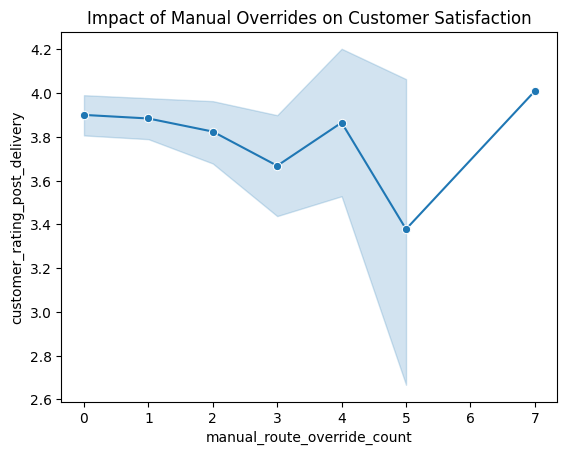

In [14]:
# Objective: See if service quality drops as overrides increase [cite: 93-94]
sns.lineplot(x='manual_route_override_count', y='customer_rating_post_delivery', data=master_df, marker='o')
plt.title("Impact of Manual Overrides on Customer Satisfaction")

/tmp/ipykernel_3782/1867323761.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cost_efficiency', data=master_df, palette='viridis')


Text(0.5, 1.0, 'Distribution of Journey Efficiency')

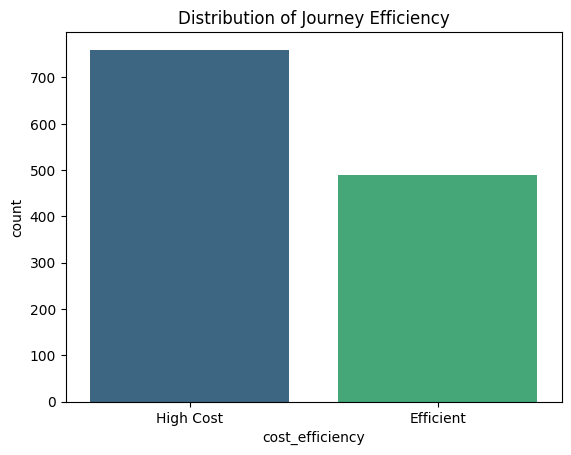

In [15]:
# Objective: Visualize how many journeys are actually "Efficient"
sns.countplot(x='cost_efficiency', data=master_df, palette='viridis')
plt.title("Distribution of Journey Efficiency")

Impact of Operational Pressure on Customer Satisfaction

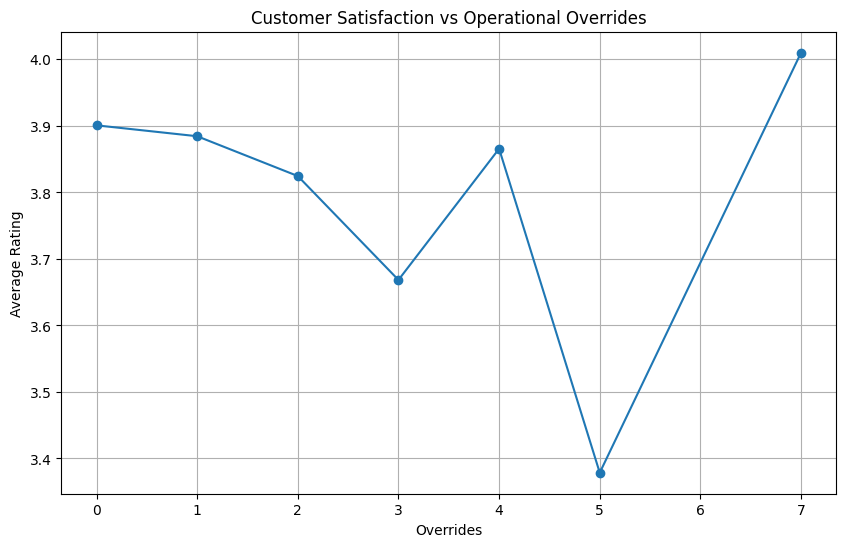

In [16]:
rating_trend = master_df.groupby(
    'manual_route_override_count'
)['customer_rating_post_delivery'].mean()

plt.figure(figsize=(10, 6))

rating_trend.plot(marker='o')

plt.title(
    "Customer Satisfaction vs Operational Overrides"
)

plt.xlabel("Overrides")
plt.ylabel("Average Rating")

plt.grid(True)

plt.show()